# Bài tập Buổi 5 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


## 0. Chuẩn bị môi trường

Ô này đã viết sẵn — chạy để nạp thư viện. Nếu thiếu thư viện, cài bằng `pip install pandas numpy matplotlib seaborn scikit-learn`.

In [256]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [257]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [258]:
# TODO 1a: in tỷ lệ missing của tất cả các cột
print("Tỷ lệ missing của các cột:")
print(df.isnull().sum() / len(df) * 100)

# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
leaky = ['alive', 'who', 'adult_male', 'class', 'deck', 'embark_town', 'alone']      

# Sử dụng drop để loại bỏ các cột này khỏi dataframe
df = df.drop(columns=leaky)

print("\nCác cột còn lại:", list(df.columns))

Tỷ lệ missing của các cột:
survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

Các cột còn lại: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


**Trả lời 1c (vì sao `alive` gây rò rỉ target):**

Cột alive (yes/no) thực chất là một cách biểu diễn khác bằng chữ của cột mục tiêu survived (1/0). Sự tương quan giữa hai cột này là $100\%$. Nếu giữ lại cột alive, mô hình học máy sẽ dễ dàng tìm ra "phím tắt" này và chỉ cần dựa hoàn toàn vào alive để đưa ra dự đoán survived, đạt độ chính xác tuyệt đối (~100%) trên tập dữ liệu mẫu.
Tuy nhiên, trong thực tế khi cần dự đoán khả năng sống sót của một hành khách mới (lúc này ta chưa biết họ sống hay chết), cột dữ liệu alive sẽ không hề tồn tại. Mô hình do không được học mối liên hệ thực tế từ các đặc trưng khác như giới tính, tuổi tác, giá vé sẽ hoàn toàn mất khả năng dự đoán.

---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [259]:
# TODO 2: shape, info, describe
print(f"Kích thước bộ dữ liệu (Số dòng, Số cột): {df.shape}")
print("Biến mục tiêu (Target variable) là: 'survived'\n")

print("--- THÔNG TIN CẤU TRÚC DỮ LIỆU ---")
print(df.info())

print("\n--- THỐNG KÊ MÔ TẢ CHO BIẾN SỐ ---")
print(df.describe())

print("\n--- THỐNG KÊ MÔ TẢ CHO BIẾN PHÂN LOẠI ---")
print(df.describe(include=['object', 'category']))

Kích thước bộ dữ liệu (Số dòng, Số cột): (891, 8)
Biến mục tiêu (Target variable) là: 'survived'

--- THÔNG TIN CẤU TRÚC DỮ LIỆU ---
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    str    
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB
None

--- THỐNG KÊ MÔ TẢ CHO BIẾN SỐ ---
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102

C:\Users\Admin\AppData\Local\Temp\ipykernel_5676\2453900798.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include=['object', 'category']))


**Trả lời 2 (biến số vs biến phân loại):**

Biến số (Numerical variables): 
* age (liên tục - continuous)

* fare (liên tục - continuous)

* sibsp (rời rạc - discrete)

* parch (rời rạc - discrete)

Biến phân loại (Categorical variables):

* sex (Nominal - nhị phân)

* embarked (Nominal - đa phân loại)

Biến thứ tự (Ordinal variables): * pclass (Dạng số 1, 2, 3 nhưng bản chất đại diện cho thứ hạng vé: Hạng 1 > Hạng 2 > Hạng 3).

---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

In [260]:
# TODO 3: bảng missing (count + %)
missing_count = df.isnull().sum()
missing_percent = df.isnull().mean() * 100

missing_table = pd.DataFrame({
    'Số lượng thiếu': missing_count,
    'Phần trăm thiếu (%)': missing_percent
})

# Chỉ hiển thị các cột bị thiếu giá trị
print(missing_table[missing_table['Số lượng thiếu'] > 0])

          Số lượng thiếu  Phần trăm thiếu (%)
age                  177            19.865320
embarked               2             0.224467


**Trả lời 3 (đề xuất xử lý cho từng cột thiếu):**

| Cột | % thiếu | Cách xử lý đề xuất | Lý do |
| :--- | :--- | :--- | :--- |
| **age** | ~19.87% | Điền giá trị khuyết bằng **Median** (Trung vị) | Phân phối của cột age thường bị lệch và có thể chứa một số outlier lớn tuổi. Median có tính bền vững (robust) cao, không bị kéo theo bởi outlier như Mean (Trung bình). |
| **embarked** | ~0.22% | Điền giá trị khuyết bằng **Mode** (Yếu vị) | Vì embarked là biến phân loại dạng chữ (S, C, Q) với số lượng thiếu cực kỳ ít (chỉ 2 dòng), phương pháp đơn giản và hiệu quả nhất là điền bằng bến cảng xuất phát phổ biến nhất (Mode). |


---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

In [261]:
# TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'
def dem_outlier_iqr(s):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return ((s < lower_bound) | (s > upper_bound)).sum()

def dem_outlier_zscore(s, nguong=3.0):
    # Loại bỏ tạm thời giá trị NaN để tính Z-score chính xác
    clean_s = s.dropna()
    z_scores = np.abs(stats.zscore(clean_s))
    return (z_scores > nguong).sum()

for col in ["age", "fare"]:
    print(f"--- Cột '{col}' ---")
    print(f"Số lượng outlier theo IQR: {dem_outlier_iqr(df[col])}")
    print(f"Số lượng outlier theo Z-score: {dem_outlier_zscore(df[col])}")

--- Cột 'age' ---
Số lượng outlier theo IQR: 11
Số lượng outlier theo Z-score: 2
--- Cột 'fare' ---
Số lượng outlier theo IQR: 116
Số lượng outlier theo Z-score: 20


**Trả lời 4 (quyết định với outlier của `fare`):**

Quyết định: Giữ lại các outlier của cột fare.

- Lý do: Các giá trị vé cao bất thường (ví dụ: $512\$$) không phải lỗi nhập liệu mà phản ánh thực tế lịch sử về giá vé phòng suite sang trọng hạng nhất (First Class) trên tàu Titanic. Những người giàu có mua vé đắt tiền này thường ở các tầng trên cận kề mạn boong cứu sinh, có tỷ lệ sống sót cao vượt trội so với các hành khách mua vé giá rẻ ở các tầng đáy tàu. Đây là thông tin cực kỳ đắt giá giúp mô hình dự đoán chính xác, do đó loại bỏ chúng sẽ làm mất đi quy luật thực tế quan trọng này.

---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

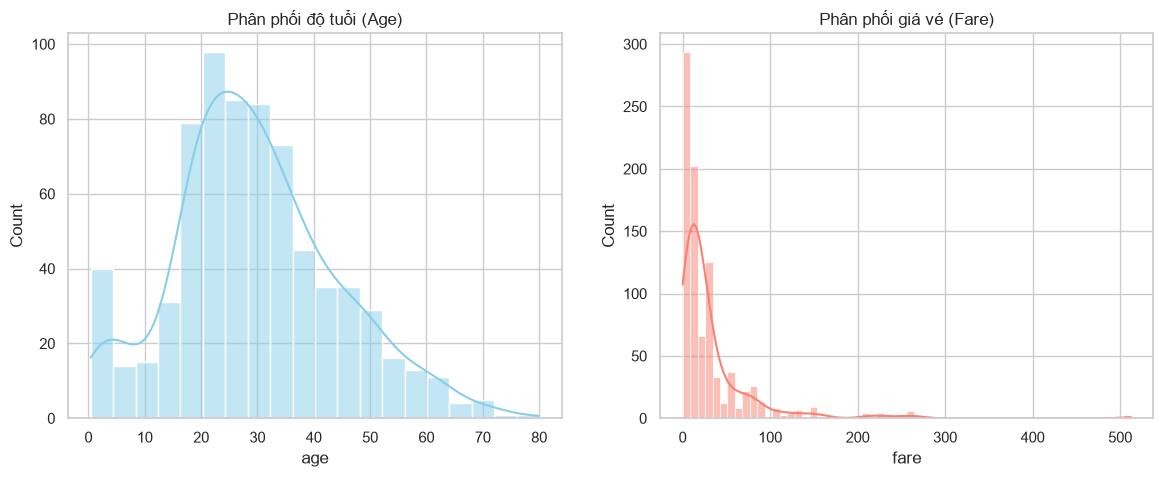

In [262]:
# TODO 5a: Histogram age & fare
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x="age", kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Phân phối độ tuổi (Age)")

sns.histplot(data=df, x="fare", kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Phân phối giá vé (Fare)")
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_5676\3425006188.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="pclass", y="fare", palette="Set2")


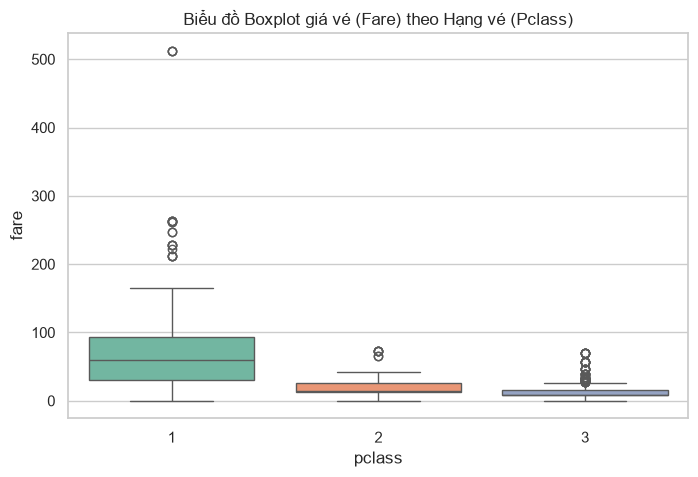

In [263]:
# TODO 5b: Boxplot fare theo survived hoặc pclass
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="pclass", y="fare", palette="Set2")
plt.title("Biểu đồ Boxplot giá vé (Fare) theo Hạng vé (Pclass)")
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_5676\665769308.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="sex", y="survived", ax=axes[0], palette="pastel", ci=None)
C:\Users\Admin\AppData\Local\Temp\ipykernel_5676\665769308.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="sex", y="survived", ax=axes[0], palette="pastel", ci=None)
C:\Users\Admin\AppData\Local\Temp\ipykernel_5676\665769308.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="pclass", y="survived", ax=axes[1], palette="muted", ci=None)
C:\Users\Admin\AppData\Local\Temp\ipykernel_5676\665769308.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign th

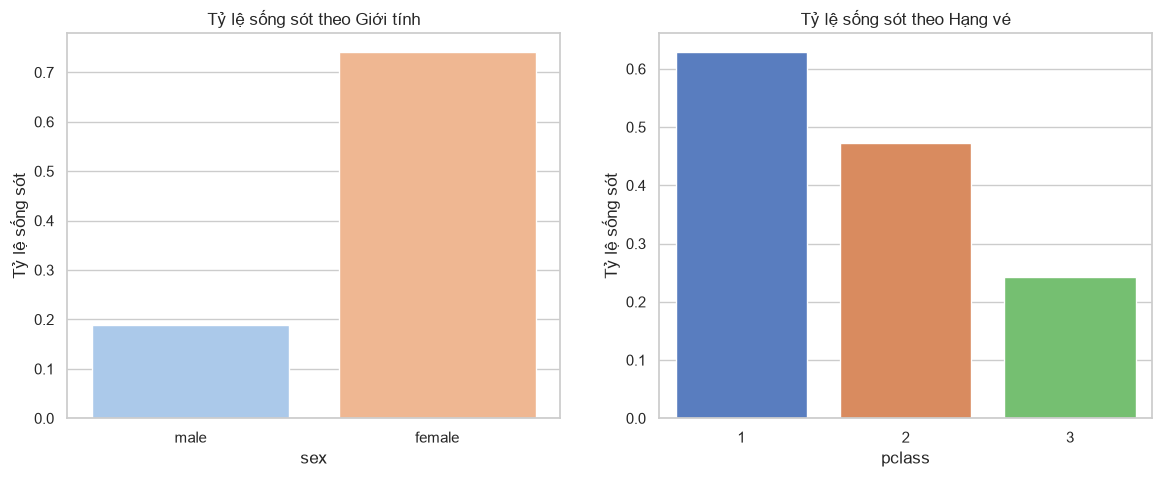

In [264]:
# TODO 5c: Barplot tỷ lệ sống sót theo sex và pclass
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=df, x="sex", y="survived", ax=axes[0], palette="pastel", ci=None)
axes[0].set_title("Tỷ lệ sống sót theo Giới tính")
axes[0].set_ylabel("Tỷ lệ sống sót")

sns.barplot(data=df, x="pclass", y="survived", ax=axes[1], palette="muted", ci=None)
axes[1].set_title("Tỷ lệ sống sót theo Hạng vé")
axes[1].set_ylabel("Tỷ lệ sống sót")
plt.show()

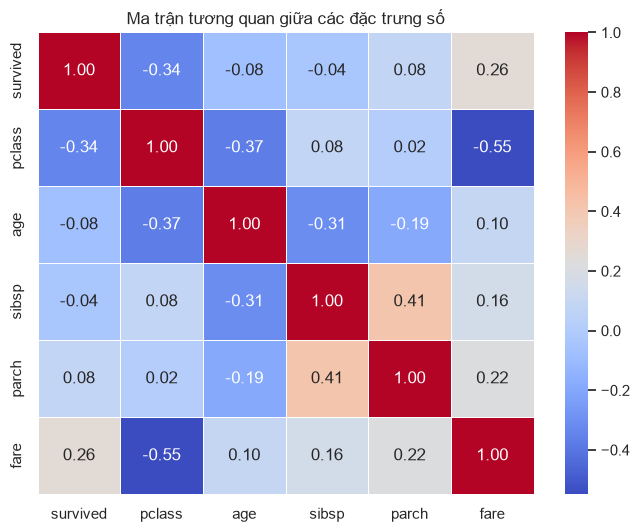

In [265]:
# TODO 5d: Heatmap correlation
plt.figure(figsize=(8, 6))
# Lọc các cột kiểu số để tính tương quan
numerical_df = df.select_dtypes(include=["number"])
sns.heatmap(numerical_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Ma trận tương quan giữa các đặc trưng số")
plt.show()

**Nhận xét 5 (viết cho từng biểu đồ ở trên):**

- **Histogram**: Độ tuổi (age) có phân phối chuẩn gần như đối xứng nhưng hơi lệch nhẹ về bên phải, tập trung nhiều nhất ở nhóm thanh niên từ $20 - 40$ tuổi. Ngược lại, giá vé (fare) bị lệch phải cực kỳ nặng (Right-skewed) với phần lớn hành khách mua vé giá rẻ ($< 50\$$) và một số rất ít khách siêu giàu mua vé giá cực kỳ đắt.
- **Boxplot**: Có sự phân hóa rõ rệt về giá vé giữa các phân hạng. Hạng vé số 1 (pclass = 1) có dải giá vé rất rộng và chứa vô số outlier có giá trị cực cao. Hạng 2 và 3 có giá vé thấp ổn định và ít biến động hơn.
- **Bar survival**: Tỷ lệ sống sót có sự bất đối xứng rất lớn: Phụ nữ có tỷ lệ sống sót vượt trội (~$74\%$) so với nam giới (~$19\%$). Xét theo hạng vé, hành khách mua vé Hạng 1 có tỷ lệ sống sót cao nhất (~$63\%$) và giảm dần xuống Hạng 2, thấp nhất là Hạng 3 (~$24\%$).
- **Heatmap**: Cặp biến có tương quan âm mạnh nhất là pclass và fare ($-0.55$), điều này hoàn toàn hợp lý vì hạng vé càng nhỏ (Hạng 1 là tốt nhất) thì giá vé càng cao. Cột survived tương quan âm với pclass ($-0.34$) cho thấy hạng vé càng thấp thì cơ hội sống sót càng giảm, và tương quan dương nhẹ với fare ($0.26$).

---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [266]:
# TODO 6: chia train/val/test có stratify
X = df.drop(columns=["survived"])
y = df["survived"]

# Bước 1: Chia tập train_tmp và test (15% test)
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Bước 2: Chia tiếp tập train_tmp thành train và validation (15% trên tổng số mẫu ban đầu ~ 17.6% trên tập tmp)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.1765, random_state=42, stratify=y_tmp
)

print(f"Kích thước tập Train: {X_train.shape}, {y_train.shape}")
print(f"Kích thước tập Val:   {X_val.shape}, {y_val.shape}")
print(f"Kích thước tập Test:  {X_test.shape}, {y_test.shape}\n")

print("--- KIỂM TRA TỶ LỆ SỐNG SÓT (STRATIFY) ---")
print(f"Tỷ lệ sống sót tập Train : {y_train.mean():.4f}")
print(f"Tỷ lệ sống sót tập Val   : {y_val.mean():.4f}")
print(f"Tỷ lệ sống sót tập Test  : {y_test.mean():.4f}")

Kích thước tập Train: (623, 7), (623,)
Kích thước tập Val:   (134, 7), (134,)
Kích thước tập Test:  (134, 7), (134,)

--- KIỂM TRA TỶ LỆ SỐNG SÓT (STRATIFY) ---
Tỷ lệ sống sót tập Train : 0.3836
Tỷ lệ sống sót tập Val   : 0.3881
Tỷ lệ sống sót tập Test  : 0.3806


---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [267]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so  = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  RobustScaler())  # Chọn RobustScaler do cột fare có nhiều outlier lệch nặng
])

pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer([
    ("num", pipe_so,  num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols)
])
preprocess.fit(X_train)               

# Tiến hành transform trên cả 3 tập
X_train_t = preprocess.transform(X_train)
X_val_t   = preprocess.transform(X_val)
X_test_t  = preprocess.transform(X_test)

print("Kích thước X_train sau khi biến đổi:", X_train_t.shape)
print("Danh sách các cột đặc trưng mới sau khi xử lý:")
print(list(preprocess.get_feature_names_out()))

Kích thước X_train sau khi biến đổi: (623, 10)
Danh sách các cột đặc trưng mới sau khi xử lý:
['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_female', 'cat__sex_male', 'cat__embarked_C', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']


**Trả lời 7 (vì sao fit chỉ trên train tránh leakage):**

- Nếu chúng ta fit bộ tiền xử lý (như tính toán trung vị median để điền khuyết, hay tính mean và variance để chuẩn hóa) trên toàn bộ tập dữ liệu (bao gồm cả tập Validation và Test), thì thông tin thống kê từ tương lai (tập Test) đã vô tình được đưa vào quá trình chuẩn bị dữ liệu cho tập Train.
Điều này khiến mô hình học máy được tiếp xúc gián tiếp với thông tin của tập Test từ trước. Khi đánh giá, mô hình sẽ đạt điểm số rất cao (ảo), nhưng khi đem ra dự đoán thực tế bên ngoài, độ chính xác sẽ sụt giảm nghiêm trọng. Việc chỉ fit trên tập Train và áp dụng tham số đó để transform lên các tập còn lại đảm bảo tập Test hoàn toàn cô lập, mô phỏng đúng kịch bản dữ liệu thực tế ngoài đời thực.

---
## Task 8 — Câu hỏi tư duy: chọn metric đánh giá

### Mục đích
Buổi học nhấn mạnh: **không có metric tốt nhất tuyệt đối** — phải chọn theo bài toán và mức mất cân bằng dữ liệu. Bài này không cần code, chỉ cần lập luận.

### Yêu cầu — trả lời ngắn gọn:
1. Biến mục tiêu `survived` có **mất cân bằng** không? (tính tỷ lệ hai lớp để trả lời).
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?

In [268]:
# TODO 8: tính tỷ lệ hai lớp của 'survived' để hỗ trợ trả lời
ti_le = df['survived'].value_counts(normalize=True) * 100
print("Tỷ lệ phân bổ các lớp của biến mục tiêu 'survived':")
print(f"Tử vong (0): {ti_le[0]:.2f}%")
print(f"Sống sót (1): {ti_le[1]:.2f}%")

Tỷ lệ phân bổ các lớp của biến mục tiêu 'survived':
Tử vong (0): 61.62%
Sống sót (1): 38.38%


**Trả lời 8:**

1. **Mức độ mất cân bằng:** Biến mục tiêu survived có sự mất cân bằng nhẹ đến trung bình ($61.62\%$ tử vong so với $38.38\%$ sống sót). Tỷ lệ này chưa đạt mức mất cân bằng cực đoan (như nhận diện gian lận tín dụng) nhưng đã đủ để tạo ra sự sai lệch nếu dùng các chỉ số đánh giá thô sơ.

2. **Sự đánh lừa của Accuracy (Độ chính xác):** Nếu tập dữ liệu mất cân bằng nghiêm trọng (ví dụ $95\%$ tử vong và chỉ $5\%$ sống sót), một mô hình "ngốc" chỉ cần đoán mò toàn bộ hành khách đều tử vong thì cũng dễ dàng đạt mức Accuracy lên tới $95\%$. Tuy nhiên, mô hình này hoàn toàn vô dụng vì nó bỏ sót $100\%$ những người thực sự sống sót. Do đó Accuracy dễ tạo ra ảo tưởng về một mô hình tốt khi dữ liệu mất cân bằng.

3. **Ưu tiên metric nào cho Titanic:** Với bài toán Titanic, chúng ta nên ưu tiên sử dụng chỉ số F1-Score.

- **Lý do:** F1-Score là trung bình điều hòa giữa Precision (Độ chính xác trên các ca dự đoán sống sót) và Recall (Khả năng tìm kiếm, bao phủ hết các ca thực sự sống sót). Việc cân bằng cả hai yếu tố này giúp đảm bảo mô hình dự đoán đúng nhóm người sống sót mà không bị đánh lừa bởi sự chênh lệch số lượng mẫu tử vong lớn hơn trong tập dữ liệu.

---
## Task 9 — Nhận xét tổng hợp về dữ liệu

### Mục đích
Khép lại toàn bộ EDA bằng một bản tóm tắt như một data analyst gửi cho đồng đội: **những gì đáng chú ý nhất** về bộ dữ liệu này.

### Yêu cầu — viết ít nhất 5 gạch đầu dòng, dựa trên **bằng chứng** (số liệu / biểu đồ) ở trên:
- Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh)
- Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?
- Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?
- Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?
- Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

**Nhận xét tổng hợp của bạn:**

1. **Đặc trưng tương quan mạnh nhất:** Đặc trưng có liên quan mạnh mẽ nhất đến khả năng sống sót là Giới tính (sex) và Hạng vé (pclass). Số liệu từ biểu đồ Barplot chứng minh tỷ lệ sống sót của nữ giới cao gấp gần 4 lần nam giới (~$74\%$ so với ~$19\%$), và hành khách ở hạng ghế sang trọng (Hạng 1) có cơ hội sống sót gấp 2.6 lần hành khách ở hạng phổ thông (Hạng 3).

2. **Cột thiếu nhiều nhất và cách xử lý:** Cột bị thiếu nhiều nhất ban đầu là deck (~77% missing) đã được loại bỏ hoàn toàn do không đủ lượng thông tin có ích. Cột age (~19.87% missing) được giữ lại và xử lý thông qua pipeline bằng phương pháp điền giá trị khuyết bằng trung vị (median) trên tập huấn luyện để đảm bảo không bị ảnh hưởng bởi các giá trị outlier lớn tuổi.

3. **Mất cân bằng dữ liệu & lựa chọn metric:** Biến mục tiêu survived bị mất cân bằng nhẹ với tỷ lệ phân bổ tử vong/sống sót là $61.62\% / 38.38\%$. Do đó, việc đánh giá mô hình bằng **F1-Score** hoặc **ROC-AUC** sẽ đáng tin cậy hơn nhiều so với việc chỉ sử dụng độ chính xác thuần túy (Accuracy).

4. **Các đặc trưng cần Scaling & Encoding:** Các biến số liên tục có biên độ lớn và chứa nhiều outlier như fare cần được chuẩn hóa bằng RobustScaler (để các giá trị ngoại lệ không làm lệch dải scale dữ liệu). Các biến số khác như age, sibsp, parch cũng cần scale về cùng một hệ quy chiếu để hỗ trợ các mô hình tính khoảng cách (như KNN, SVM) hay tuyến tính.

5. **Điều bất ngờ/thú vị rút ra từ dữ liệu:** Sự phân hóa giai cấp xã hội thể hiện cực kỳ rõ rệt qua biến cố lịch sử này: Dù cùng chung một hoàn cảnh tai nạn bất ngờ, nhưng những hành khách giàu có mua vé Hạng 1 không chỉ được hưởng điều kiện tiện nghi tốt hơn, mà cơ hội sống sót của họ cũng cao hơn rất nhiều so với những hành khách Hạng 3 ở tầng đáy boong tàu. Giá trị đồng tiền bỏ ra cho chiếc vé tàu thực sự đã trực tiếp định đoạt ranh giới giữa sự sống và cái chết trong thảm họa này.

---
## (Bonus — không bắt buộc) Thử thách nâng cao

Chọn **một** trong các hướng sau nếu bạn muốn thử sức:

1. **Feature engineering:** tạo đặc trưng mới `family_size = sibsp + parch + 1`, hoặc trích `title` (Mr/Mrs/Miss...) từ tên (nếu dùng bản có cột `name`). Kiểm tra tương quan với `survived`.
2. **So sánh scaler:** vẽ phân phối `fare` trước và sau khi áp `StandardScaler`, `MinMaxScaler`, `RobustScaler`. Nhận xét scaler nào phù hợp nhất với dữ liệu lệch + có outlier.
3. **Bẫy KNN:** thử `KNNImputer` để điền `age` **khi chưa scale** và **sau khi đã scale** `fare`. Quan sát kết quả có khác nhau không, và giải thích tại sao (gợi ý: khoảng cách Euclid bị chi phối bởi cột thang đo lớn).

In [269]:
# (tùy chọn) code cho phần Bonus
...

---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không lỗi.
- [ ] Đã bỏ các cột rò rỉ/dư thừa (Task 1) và giải thích được vì sao.
- [ ] Mỗi biểu đồ (Task 5) đều có **nhận xét**.
- [ ] Đã **chia tập trước**, tiền xử lý **fit chỉ trên train** (Task 6–7).
- [ ] Đã trả lời tất cả các phần *"Trả lời:"*.
- [ ] Nhận xét tổng hợp (Task 9) có **ít nhất 5 ý** dựa trên bằng chứng.
- [ ] Đã push lên **repo cá nhân trên GitHub**.
